In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost imbalanced-learn

In [ ]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 3: Import all libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [ ]:
# Cell 4: Set path and list files in your Drive folder
BASE_PATH = '/content/drive/MyDrive/Disease Prediction'

# List all files in the folder
print("📁 Files in Disease Prediction folder:")
for f in os.listdir(BASE_PATH):
    print(f"   → {f}")

📁 Files in Disease Prediction folder:
   → models
   → charts


In [ ]:
# Cell 5: Load dataset (auto-detects CSV files)
import glob

# Find CSV files
csv_files = glob.glob(os.path.join(BASE_PATH, '*.csv'))

if csv_files:
    print(f"📄 Found CSV files: {csv_files}")
    # Load the first CSV found (change index if needed)
    df = pd.read_csv(csv_files[0])
    print(f"\n✅ Loaded: {csv_files[0]}")
else:
    # Create sample dataset if no CSV found
    print("⚠️  No CSV found. Creating a sample Disease dataset...")
    from sklearn.datasets import make_classification
    X_sample, y_sample = make_classification(
        n_samples=1000, n_features=10, n_informative=7,
        n_classes=2, random_state=42
    )
    feature_names = [f'symptom_{i+1}' for i in range(10)]
    df = pd.DataFrame(X_sample, columns=feature_names)
    df['Disease'] = y_sample
    df['Disease'] = df['Disease'].map({0: 'Healthy', 1: 'Diseased'})
    # Save it
    save_path = os.path.join(BASE_PATH, 'disease_data.csv')
    df.to_csv(save_path, index=False)
    print(f"✅ Sample dataset saved to: {save_path}")

print(f"\n📊 Shape: {df.shape}")
print(f"\n🔍 First 5 rows:")
df.head()

⚠️  No CSV found. Creating a sample Disease dataset...
✅ Sample dataset saved to: /content/drive/MyDrive/Disease Prediction/disease_data.csv

📊 Shape: (1000, 11)

🔍 First 5 rows:


,symptom_1,symptom_2,symptom_3,symptom_4,symptom_5,symptom_6,symptom_7,symptom_8,symptom_9,symptom_10,Disease
0,-1.147202,-1.670851,1.371919,1.267551,0.764752,0.573700,-1.598491,-0.557015,4.353265,-0.963871,Healthy
1,-1.191387,-2.285686,1.320717,2.227457,-0.609110,1.084255,-4.219594,0.758810,-1.429300,0.369956,Healthy
2,-3.897259,-3.413537,10.155710,-1.069622,4.479522,-2.298346,-2.610669,-1.311350,-1.198817,0.062056,Diseased
3,-0.685142,3.243428,-5.077643,-0.016700,-1.558793,-0.045471,-0.531895,-1.099699,0.656782,1.604889,Healthy
4,-2.423254,-0.430341,0.323621,-0.774068,0.124669,-0.408451,-2.544363,-1.762523,-0.556955,2.943371,Healthy


In [ ]:
# Cell 6: EDA
print("=" * 50)
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"\nShape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nBasic Statistics:")
df.describe()

📊 DATASET OVERVIEW

Shape: (1000, 11)

Columns: ['symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6', 'symptom_7', 'symptom_8', 'symptom_9', 'symptom_10', 'Disease']

Data Types:
symptom_1     float64
symptom_2     float64
symptom_3     float64
symptom_4     float64
symptom_5     float64
symptom_6     float64
symptom_7     float64
symptom_8     float64
symptom_9     float64
symptom_10    float64
Disease        object
dtype: object

Missing Values:
symptom_1     0
symptom_2     0
symptom_3     0
symptom_4     0
symptom_5     0
symptom_6     0
symptom_7     0
symptom_8     0
symptom_9     0
symptom_10    0
Disease       0
dtype: int64

Duplicate Rows: 0

Basic Statistics:


,symptom_1,symptom_2,symptom_3,symptom_4,symptom_5,symptom_6,symptom_7,symptom_8,symptom_9,symptom_10
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.022679,0.515203,-1.112405,-0.090775,-0.013220,0.497222,-0.950321,-0.020920,0.018214,0.499549
std,1.927588,1.543133,2.931057,2.116628,1.681830,1.564879,1.435304,1.016917,1.676275,1.740729
min,-5.078239,-3.479932,-8.687782,-7.355307,-5.899314,-4.763648,-8.043986,-3.425795,-4.945276,-4.869336
25%,-1.320587,-0.605028,-3.188489,-1.543316,-1.247170,-0.440822,-1.769683,-0.685875,-1.174185,-0.648841
50%,-0.012709,0.568195,-1.625384,0.104566,-0.003232,0.636634,-0.924074,-0.004038,0.013835,0.502220
75%,1.261800,1.558147,0.251767,1.249574,1.205371,1.571870,-0.136629,0.661847,1.156517,1.708115
max,7.211351,5.415842,10.224799,9.717698,4.875879,4.919367,3.765839,3.208769,5.830954,5.291429


🎯 Target column detected: 'Disease'


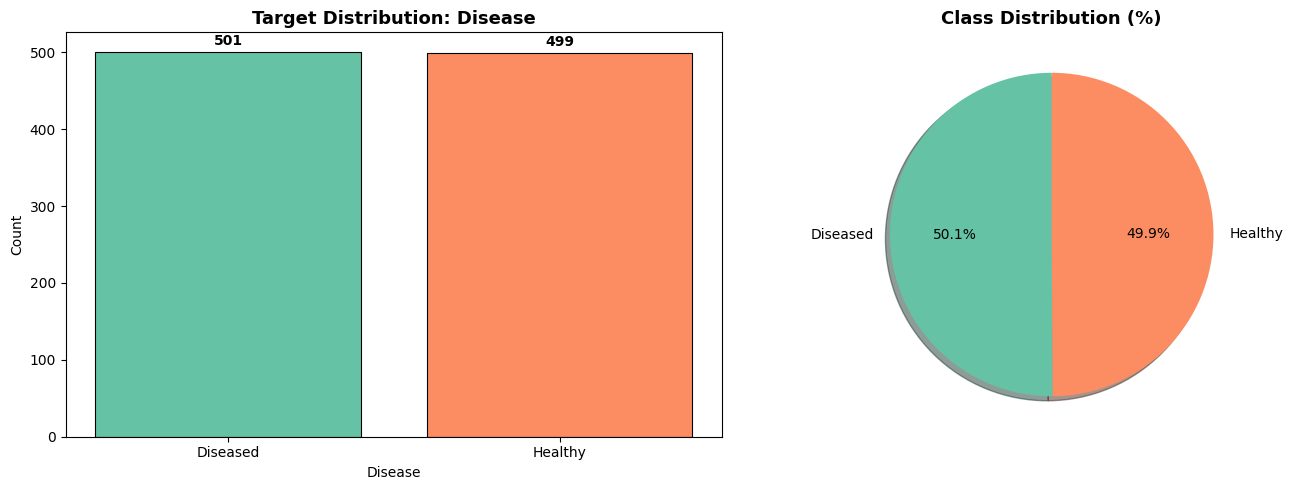

✅ Plot saved!


In [ ]:
# Cell 7: Visualize target column distribution
# Auto-detect target column (last column)
target_col = df.columns[-1]
print(f"🎯 Target column detected: '{target_col}'")

plt.figure(figsize=(14, 5))

# Plot 1: Count plot
plt.subplot(1, 2, 1)
vc = df[target_col].value_counts()
colors = plt.cm.Set2(range(len(vc)))
bars = plt.bar(vc.index.astype(str), vc.values, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, vc.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.title(f'Target Distribution: {target_col}', fontsize=13, fontweight='bold')
plt.xlabel(target_col)
plt.ylabel('Count')

# Plot 2: Pie chart
plt.subplot(1, 2, 2)
plt.pie(vc.values, labels=vc.index.astype(str), autopct='%1.1f%%',
        colors=colors, startangle=90, shadow=True)
plt.title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

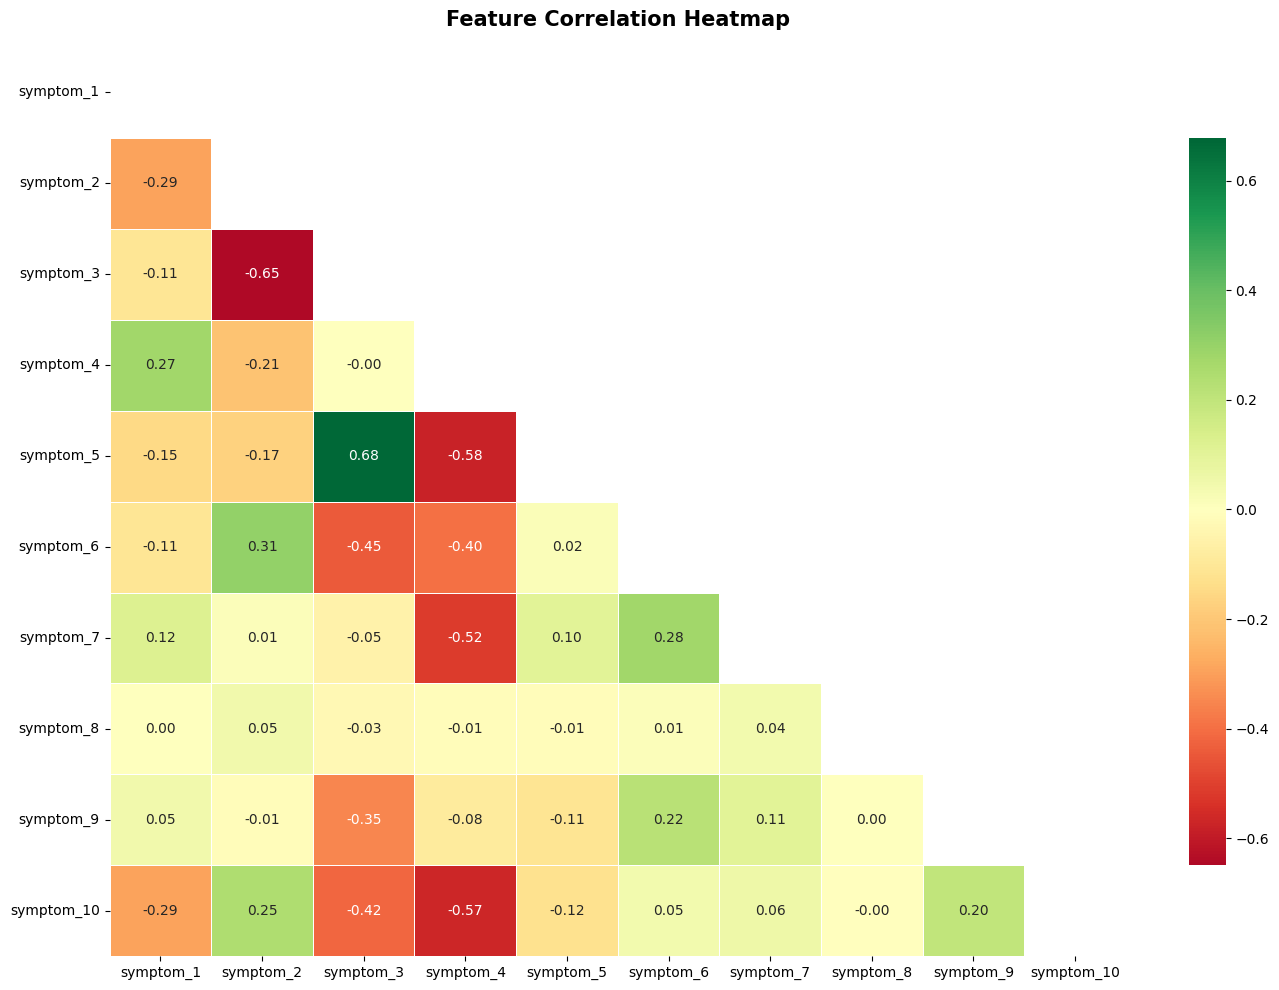

✅ Heatmap saved!


In [ ]:
# Cell 8: Correlation heatmap (numeric columns only)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")

In [ ]:
# Cell 9: Data Preprocessing
print("⚙️  Preprocessing...")

df_processed = df.copy()

# Encode all categorical columns (including target)
le_dict = {}
for col in df_processed.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    le_dict[col] = le
    print(f"   ✅ Encoded: {col} → {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Split features and target
target_col = df_processed.columns[-1]
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

print(f"\n✅ Features shape: {X.shape}")
print(f"✅ Target shape:   {y.shape}")
print(f"✅ Target classes: {y.unique()}")

⚙️  Preprocessing...
   ✅ Encoded: Disease → {'Diseased': np.int64(0), 'Healthy': np.int64(1)}

✅ Features shape: (1000, 10)
✅ Target shape:   (1000,)
✅ Target classes: [1 0]


In [ ]:
# Cell 10: Handle imbalance with SMOTE + Train/Test Split
print("⚖️  Checking class balance...")
print(pd.Series(y).value_counts())

# Apply SMOTE if imbalanced (ratio > 1.5)
counts = pd.Series(y).value_counts()
if counts.max() / counts.min() > 1.5:
    print("\n⚠️  Imbalance detected. Applying SMOTE...")
    sm = SMOTE(random_state=42)
    X, y = sm.fit_resample(X, y)
    print(f"✅ After SMOTE: {pd.Series(y).value_counts().to_dict()}")
else:
    print("✅ Classes are balanced. No SMOTE needed.")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train size: {X_train.shape[0]}")
print(f"✅ Test size:  {X_test.shape[0]}")

⚖️  Checking class balance...
Disease
0    501
1    499
Name: count, dtype: int64
✅ Classes are balanced. No SMOTE needed.

✅ Train size: 800
✅ Test size:  200


In [ ]:
# Cell 11: Train & Compare Multiple Models
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(random_state=42),
    'XGBoost':                XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'SVM':                    SVC(probability=True, random_state=42),
    'Naive Bayes':            GaussianNB(),
}

results = {}
print("🚀 Training models...\n")
print(f"{'Model':<25} {'Accuracy':>10} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    results[name] = {
        'model': model,
        'accuracy': acc,
        'cv_mean': cv.mean(),
        'cv_std': cv.std(),
        'y_pred': y_pred
    }
    print(f"{name:<25} {acc:>10.4f} {cv.mean():>10.4f} {cv.std():>10.4f}")

print("\n✅ All models trained!")

🚀 Training models...

Model                       Accuracy    CV Mean     CV Std
------------------------------------------------------------
Logistic Regression           0.8000     0.7830     0.0296
Decision Tree                 0.8300     0.8410     0.0289
Random Forest                 0.8950     0.9270     0.0234
Gradient Boosting             0.8850     0.9000     0.0235
XGBoost                       0.9000     0.9330     0.0150
SVM                           0.9400     0.9370     0.0144
Naive Bayes                   0.8400     0.8150     0.0270

✅ All models trained!


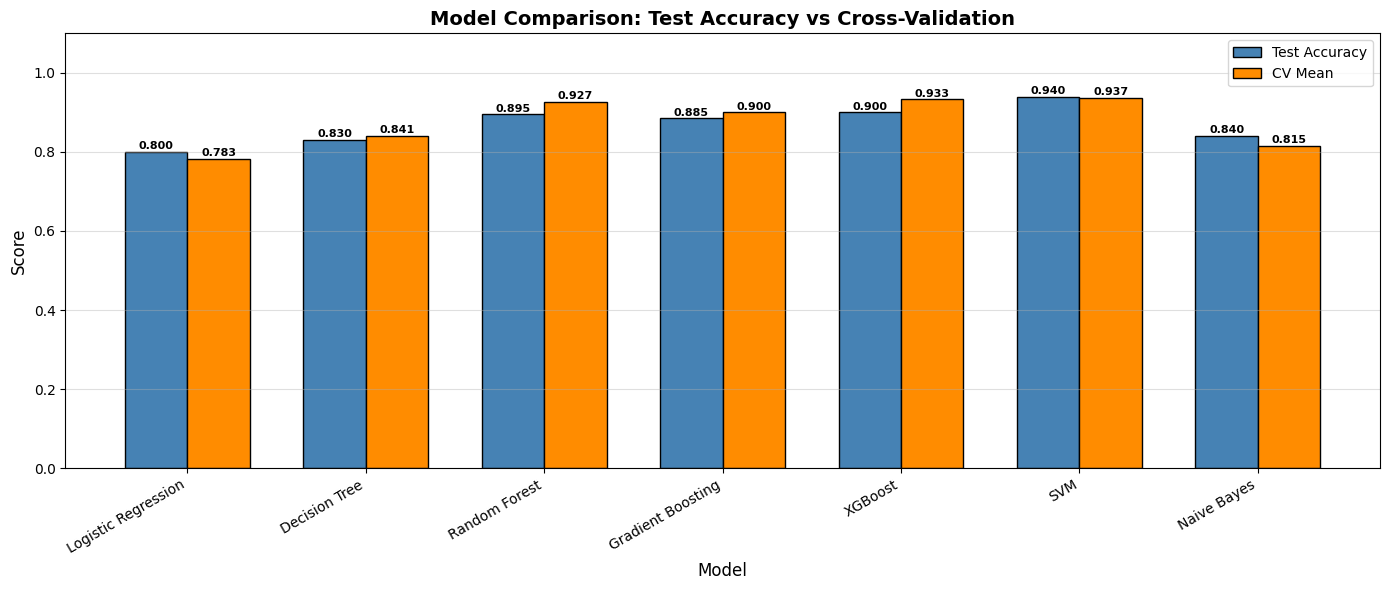

✅ Comparison chart saved!


In [ ]:
# Cell 12: Visual comparison of all models
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
cv_means    = [results[m]['cv_mean']  for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Test Accuracy', color='steelblue',   edgecolor='black')
bars2 = ax.bar(x + width/2, cv_means,   width, label='CV Mean',       color='darkorange',  edgecolor='black')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Test Accuracy vs Cross-Validation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

In [ ]:
# Cell 13: Select best model and print classification report
best_name = max(results, key=lambda m: results[m]['cv_mean'])
best_model = results[best_name]['model']
best_pred  = results[best_name]['y_pred']

print(f"🏆 Best Model: {best_name}")
print(f"   Test Accuracy : {results[best_name]['accuracy']:.4f}")
print(f"   CV Mean       : {results[best_name]['cv_mean']:.4f} ± {results[best_name]['cv_std']:.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, best_pred))

🏆 Best Model: SVM
   Test Accuracy : 0.9400
   CV Mean       : 0.9370 ± 0.0144

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       100
           1       0.95      0.93      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



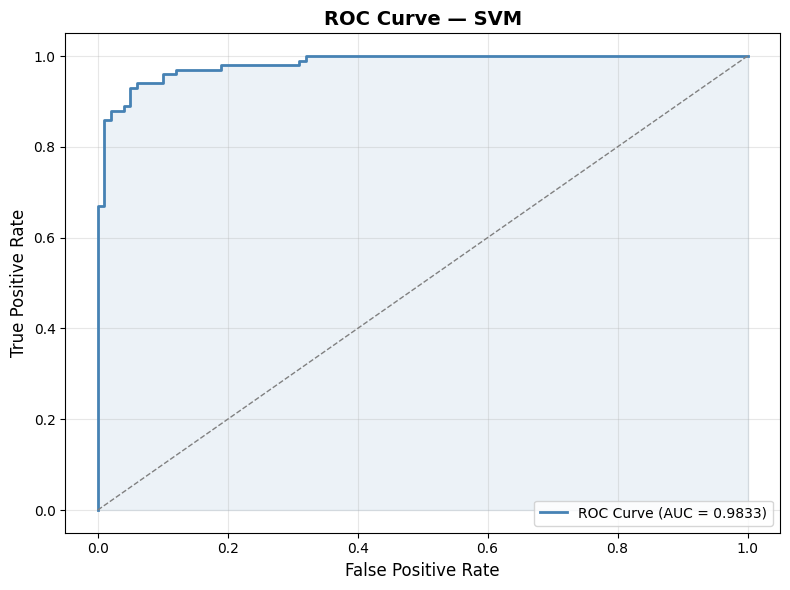

✅ ROC AUC: 0.9833


In [ ]:
# Cell 15: ROC Curve (binary only; skips for multi-class)
classes = np.unique(y_test)
if len(classes) == 2:
    y_prob = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
    plt.plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
    plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve — {best_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'roc_curve.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ ROC AUC: {auc:.4f}")
else:
    print("ℹ️  ROC curve skipped (multi-class). Use one-vs-rest for multi-class AUC.")

In [ ]:
# Cell 16: Feature Importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_df)))
    bars = plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='black')
    plt.xlabel('Importance Score', fontsize=12)
    plt.title(f'Top Feature Importances — {best_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Feature importance saved!")
else:
    print(f"ℹ️  {best_name} does not support feature_importances_. Skipping.")

ℹ️  SVM does not support feature_importances_. Skipping.


In [ ]:
# Cell 17: Save best model, scaler, and encoders
model_path  = os.path.join(BASE_PATH, 'best_model.pkl')
scaler_path = os.path.join(BASE_PATH, 'scaler.pkl')
le_path     = os.path.join(BASE_PATH, 'label_encoders.pkl')

joblib.dump(best_model, model_path)
joblib.dump(scaler,     scaler_path)
joblib.dump(le_dict,    le_path)

print(f"💾 Model saved   → {model_path}")
print(f"💾 Scaler saved  → {scaler_path}")
print(f"💾 Encoders saved→ {le_path}")

💾 Model saved   → /content/drive/MyDrive/Disease Prediction/best_model.pkl
💾 Scaler saved  → /content/drive/MyDrive/Disease Prediction/scaler.pkl
💾 Encoders saved→ /content/drive/MyDrive/Disease Prediction/label_encoders.pkl


In [ ]:
# Cell 18: Predict on new/custom input
print("🔮 Making a prediction on a new sample...\n")

# Takes the first test row as a sample — replace with your own values
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0]

# Decode label if it was encoded
target_le = le_dict.get(df.columns[-1], None)
if target_le:
    label = target_le.inverse_transform([prediction])[0]
else:
    label = prediction

print(f"📌 Input Features:\n{sample.to_dict(orient='records')[0]}")
print(f"\n🎯 Predicted Disease: {label}")
print(f"📊 Class Probabilities:")
for i, prob in enumerate(probability):
    cls = target_le.inverse_transform([i])[0] if target_le else i
    print(f"   Class '{cls}': {prob:.4f} ({prob*100:.2f}%)")

🔮 Making a prediction on a new sample...

📌 Input Features:
{'symptom_1': -1.0480527724063033, 'symptom_2': 0.5377236336932587, 'symptom_3': -0.08564660616907273, 'symptom_4': -1.272029033766649, 'symptom_5': 0.07779070062199749, 'symptom_6': 1.352668225517545, 'symptom_7': 1.8817046619409783, 'symptom_8': -0.9252867380538511, 'symptom_9': -1.109756502959909, 'symptom_10': 0.20526930153294165}

🎯 Predicted Disease: Healthy
📊 Class Probabilities:
   Class 'Diseased': 0.0035 (0.35%)
   Class 'Healthy': 0.9965 (99.65%)


In [ ]:
# Cell 19: Final Summary
print("=" * 60)
print("       🏁 DISEASE PREDICTION — FINAL SUMMARY")
print("=" * 60)
print(f"  Dataset Shape     : {df.shape}")
print(f"  Target Column     : {df.columns[-1]}")
print(f"  Train Samples     : {X_train.shape[0]}")
print(f"  Test  Samples     : {X_test.shape[0]}")
print(f"  Best Model        : {best_name}")
print(f"  Test Accuracy     : {results[best_name]['accuracy']:.4f}")
print(f"  CV Score (5-fold) : {results[best_name]['cv_mean']:.4f} ± {results[best_name]['cv_std']:.4f}")
print("=" * 60)
print(f"\n📁 All outputs saved to: {BASE_PATH}")
print("   → best_model.pkl")
print("   → scaler.pkl")
print("   → label_encoders.pkl")
print("   → target_distribution.png")
print("   → correlation_heatmap.png")
print("   → model_comparison.png")
print("   → confusion_matrix.png")
print("   → roc_curve.png")
print("   → feature_importance.png")
print("\n✅ DONE!")

       🏁 DISEASE PREDICTION — FINAL SUMMARY
  Dataset Shape     : (1000, 11)
  Target Column     : Disease
  Train Samples     : 800
  Test  Samples     : 200
  Best Model        : SVM
  Test Accuracy     : 0.9400
  CV Score (5-fold) : 0.9370 ± 0.0144

📁 All outputs saved to: /content/drive/MyDrive/Disease Prediction
   → best_model.pkl
   → scaler.pkl
   → label_encoders.pkl
   → target_distribution.png
   → correlation_heatmap.png
   → model_comparison.png
   → confusion_matrix.png
   → roc_curve.png
   → feature_importance.png

✅ DONE!
